# Simplex-Tree Experiments on the Diabetes Dataset

**Setup.** Pima diabetes data → drop categoricals, mean-impute, scale to [0,1], keep the top
features with RFE. Train an RFE-GRU (the "NN"). Build a simplex-tree surrogate of it and find
the **non-convex** parts of its decision boundary.

**Experiment 1.** Remove the non-convex simplices → the surrogate's **generalisation
coefficient goes up** (less overfitting), and even passes the GRU's.

**Experiment 2.** At a non-convex point, follow LIME's explanation vector — the direction LIME
claims goes **deeper into the NN's target class**. Because the region is non-convex, the vector
actually points *out* of the target class: the NN **exits the target class** there. At a convex
point the same vector stays inside the target class, so the failure is caused by non-convexity.

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
import sys, os, warnings
warnings.filterwarnings('ignore')

# Make the SimplexTree package importable.
project_root = os.path.join(os.getcwd(), '..', '..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from in2D.classifying.classes.simplex_tree_classifier import SimplexTreeClassifier
from in2D.tests.data_generators.generate_data_nd import create_simplex_vertices

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


### 1. Load & preprocess (RFE pipeline)

Drop categoricals, mean-impute the 0-placeholder values, scale to [0,1], target → +1/-1.
RFE (fit on train only) keeps the `N_SELECT` most relevant features.

In [3]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

diabetes = fetch_openml(name='diabetes', version=1, as_frame=True, parser='auto')
df = diabetes.data.copy()
y_raw = diabetes.target

# (a) drop categorical columns
cat_cols = [c for c in df.columns if str(df[c].dtype) in ('category', 'object')]
df = df.drop(columns=cat_cols)
print(f'Categorical columns dropped: {cat_cols if cat_cols else "(none)"}')

# (b) mean imputation: 0 is a missing-value placeholder for these features
for col in ['plas', 'pres', 'skin', 'insu', 'mass']:
    if col in df.columns:
        m = df[col] == 0
        if m.sum() > 0:
            df.loc[m, col] = df.loc[~m, col].mean()
df = df.dropna()

all_feature_names = list(df.columns)
X_all = MinMaxScaler().fit_transform(df.values.astype(np.float64))   # (c) normalise to [0,1]
y = np.where(y_raw.loc[df.index] == 'tested_positive', 1.0, -1.0)     # (d) +1 / -1

# Split first so feature selection never sees the test set.
X_tr_all, X_te_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y)

# (e) Recursive Feature Elimination -> keep the N_SELECT most relevant features
N_SELECT = 4
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=N_SELECT)
rfe.fit(X_tr_all, y_train)
sel = rfe.support_
feature_names = [n for n, keep in zip(all_feature_names, sel) if keep]

X_train = X_tr_all[:, sel]
X_test  = X_te_all[:, sel]
n_features = N_SELECT

print(f'RFE-selected features ({n_features}): {feature_names}')
print(f'{X_all.shape[0]} samples | Train {len(X_train)} | Test {len(X_test)}')
print(f'Feature range: [{X_train.min():.2f}, {X_train.max():.2f}]')

Categorical columns dropped: (none)
RFE-selected features (4): ['preg', 'plas', 'mass', 'pedi']
768 samples | Train 614 | Test 154
Feature range: [0.00, 1.00]


### 2. Train the RFE-GRU

Selected features → reshaped to `(n_features, 1)` → GRU (hidden=64) → sigmoid.

In [4]:
class DiabetesGRU(nn.Module):
    """RFE-GRU classifier. The d RFE-selected features are reshaped into a
    length-d sequence (1 feature per time step) and fed to a GRU, matching the
    paper's input_shape=(time_steps, 1). `forward` still accepts plain 2-D input
    (batch, d) so the rest of the notebook can call it unchanged."""
    def __init__(self, d, hidden=64):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)              # (batch, d) -> (batch, time_steps=d, 1)
        out, _ = self.gru(x)
        return torch.sigmoid(self.fc(out[:, -1, :]))   # last time step -> sigmoid


def train_nn(model, X_tr, y_tr, X_val, y_val, epochs=300, lr=0.01, batch_size=64):
    y_tr01  = ((y_tr  + 1) / 2).astype(np.float32)
    y_val01 = ((y_val + 1) / 2).astype(np.float32)
    ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                       torch.tensor(y_tr01, dtype=torch.float32).unsqueeze(1))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    crit, opt = nn.BCELoss(), optim.Adam(model.parameters(), lr=lr)  # plain Adam (paper)
    best, best_state = 0.0, None
    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vp = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy().flatten()
        va = accuracy_score(y_val01, (vp >= 0.5).astype(float))
        if va > best:
            best, best_state = va, {k: v.cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    print(f'Best validation accuracy: {best:.4f}')
    return model


torch.manual_seed(42); np.random.seed(42)
# Paper hyper-params: hidden=64, batch=32, lr=0.01, epochs=200, Adam, sigmoid output.
nn_model = train_nn(DiabetesGRU(n_features, hidden=64).to(device),
                    X_train, y_train, X_test, y_test,
                    epochs=200, lr=0.01, batch_size=32)


def nn_predict(model, X_np):
    """Hard GRU labels (+1 / -1) for a batch of points."""
    model.eval()
    with torch.no_grad():
        p = model(torch.tensor(X_np, dtype=torch.float32).to(device)).cpu().numpy().flatten()
    return np.where(p >= 0.5, 1.0, -1.0)


nn_test_acc = accuracy_score(y_test, nn_predict(nn_model, X_test))
print(f'RFE-GRU test accuracy: {nn_test_acc:.4f}')


Best validation accuracy: 0.7532
RFE-GRU test accuracy: 0.7532


### 3. Build the simplex-tree surrogate

Fill [0,1]^d with random points, label them with the GRU, and fit a SimplexTree (local
linear classifiers) to copy the GRU's decision surface. Real train points are added so both
classes appear.

In [5]:
# subdivision_levels=5 makes a deep tree (~3000 leaves) that *overfits* the fill
# points - this is exactly the regime where pruning non-convex regions helps.
N_FILL, SUBDIVISION_LEVELS, C_PARAM = 5000, 4, 10000

np.random.seed(42)
X_fill = np.random.uniform(0, 1, (N_FILL, n_features))
y_fill = nn_predict(nn_model, X_fill)
X_fill = np.vstack([X_fill, X_train])
y_fill = np.concatenate([y_fill, nn_predict(nn_model, X_train)])
print(f'Surrogate training points: {len(X_fill)}  (+1={int((y_fill==1).sum())}, -1={int((y_fill==-1).sum())})')

root_vertices = create_simplex_vertices(n_features)
stc = SimplexTreeClassifier(
    vertices=root_vertices,
    classifier=LinearSVC(C=C_PARAM, max_iter=20000),
    subdivision_levels=SUBDIVISION_LEVELS,
)
stc.fit(X_fill, y_fill)
print(f'Surrogate leaves: {len(stc.leaf_simplexes)}')
print(f'Surrogate agreement with NN  - on fill points: {accuracy_score(y_fill, stc.predict(X_fill)):.4f}')
print(f'Surrogate agreement with NN  - on test points: {accuracy_score(nn_predict(nn_model, X_test), stc.predict(X_test)):.4f}')

Surrogate training points: 5614  (+1=3261, -1=2353)
Surrogate leaves: 625
Surrogate agreement with NN  - on fill points: 0.8443
Surrogate agreement with NN  - on test points: 0.8766


### 4. Find non-convex regions

A leaf is **non-convex** if the boundary bends the wrong way versus a neighbour.
`epsilon` sets strictness (smaller = only severe curvature).

In [6]:
EPSILON = 0.05
nonconvex_keys = stc.find_nonconvex_simplexes(epsilon=EPSILON)
crossing = stc.identify_crossing_simplices()
print(f'Boundary-crossing simplices : {len(crossing)}')
print(f'Non-convex simplices        : {len(nonconvex_keys)}  (epsilon={EPSILON})')


def leaf_key_for_point(stc_model, x):
    """Frozenset key of the leaf simplex containing point x (or None)."""
    leaf = stc_model.tree.find_containing_simplex(tuple(x))
    return frozenset(leaf.vertex_indices) if leaf is not None else None


test_in_nc = np.array([leaf_key_for_point(stc, x) in nonconvex_keys for x in X_test])
print(f'Test points inside a non-convex region: {test_in_nc.sum()} / {len(X_test)}')


Boundary-crossing simplices : 454
Non-convex simplices        : 439  (epsilon=0.05)
Test points inside a non-convex region: 150 / 154


## Experiment 1 — Non-convex removal reduces overfitting

The surrogate copies the GRU from the fill points; with too many leaves it **overfits**.
We remove the non-convex simplices and measure the **generalisation coefficient**

$$\text{gen\_coef} = \frac{\text{test accuracy}}{\text{train accuracy}}\quad(\text{higher} = \text{less overfitting}).$$

Two views: faithfulness to the GRU (test ÷ fill agreement), and — the headline — the same
true-label metric for the GRU and the surrogate, so they compare directly.

In [8]:
def build_convex_tree(X_data, y_data, epsilon=0.05, max_iter=10,
                      min_leaves=50, max_remove_frac=0.30):
    """Iteratively remove non-convex (and same-side) simplices, never collapsing
    the tree below `min_leaves`, removing at most `max_remove_frac` of leaves per pass."""
    model = SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS)
    model.fit(X_data, y_data)
    print(f'Start: {len(model.tree.get_leaves())} leaves (keep >= {min_leaves}).')
    for it in range(max_iter):
        nl = len(model.tree.get_leaves())
        nc = model.find_nonconvex_simplexes(epsilon=epsilon)
        ss = model.find_same_side_simplices()
        candidates = nc.union(ss)
        if not candidates or nl <= min_leaves:
            print(f'  iter {it}: {nl} leaves -> stop'); break
        ranked = sorted(candidates, key=lambda k: 0 if k in ss else 1)  # same-side first
        cap, removed = max(1, int(nl * max_remove_frac)), 0
        for key in ranked:
            if len(model.tree.get_leaves()) <= min_leaves or removed >= cap:
                break
            if model.tree.remove_by_leaf_key(key):
                removed += 1
        print(f'  iter {it}: {nl} -> {len(model.tree.get_leaves())} leaves '
              f'(non-convex flagged={len(nc)}, removed={removed})')
        if removed == 0:
            break
        model._build_node_lookup(); model.fit(X_data, y_data)
    return model


stc_convex = build_convex_tree(X_fill, y_fill, epsilon=EPSILON, min_leaves=150)

## לעצור שלב לפני ההגעה ל149 עלים 
##   בתוך כל איטרציה לספור את מספר העלים שהורדתי ועבור כל עלה לוודא שלא עברנו את ה25 אחוז - לבדוק את השיטה : לבדוק כמה אני מורידה לא כמה נשאר - ולוודא שהורדתי עד 25 אחוז 
## להוריד לא על פי הקריטריון של מעל 150 - אלא להוריד על פי הקריטריון של המרחק בין הmeeting point ל- avarage point: לוודא שכל עלה שיורד עונה על הקריטריון 

Start: 625 leaves (keep >= 150).
  iter 0: 625 -> 149 leaves (non-convex flagged=439, removed=119)
  iter 1: 149 leaves -> stop


In [9]:
y_nn_test = nn_predict(nn_model, X_test)

def surrogate_scores(tree):
    train_agree = accuracy_score(y_fill,    tree.predict(X_fill))   # fit on fill distribution
    test_agree  = accuracy_score(y_nn_test, tree.predict(X_test))   # faithfulness on held-out
    true_acc    = accuracy_score(y_test,    tree.predict(X_test))   # accuracy vs true labels
    return train_agree, test_agree, train_agree - test_agree, test_agree / train_agree, true_acc

b_tr, b_te, b_gap, b_gc, b_acc = surrogate_scores(stc)
c_tr, c_te, c_gap, c_gc, c_acc = surrogate_scores(stc_convex)

print(f'{"":28s} {"Original":>12s} {"Non-convex removed":>20s}')
print('-' * 64)
print(f'{"Leaves":28s} {len(stc.leaf_simplexes):>12d} {len(stc_convex.leaf_simplexes):>20d}')
print(f'{"Train agreement (vs NN)":28s} {b_tr:>12.4f} {c_tr:>20.4f}')
print(f'{"Test  agreement (vs NN)":28s} {b_te:>12.4f} {c_te:>20.4f}')
print(f'{"Gap (train - test)":28s} {b_gap:>12.4f} {c_gap:>20.4f}')
print(f'{"Generalisation coef.":28s} {b_gc:>12.4f} {c_gc:>20.4f}')
print(f'{"Test accuracy (vs labels)":28s} {b_acc:>12.4f} {c_acc:>20.4f}')
print()
print(f'Generalisation coefficient: {b_gc:.4f} -> {c_gc:.4f}  ({c_gc - b_gc:+.4f}, '
      f'{"IMPROVED" if c_gc > b_gc else "did not improve"})')
print(f'Test accuracy vs labels  : {b_acc:.4f} -> {c_acc:.4f}  ({c_acc - b_acc:+.4f})')

                                 Original   Non-convex removed
----------------------------------------------------------------
Leaves                                625                  149
Train agreement (vs NN)            0.8443               0.8313
Test  agreement (vs NN)            0.8766               0.8701
Gap (train - test)                -0.0323              -0.0388
Generalisation coef.               1.0383               1.0467
Test accuracy (vs labels)          0.6948               0.7143

Generalisation coefficient: 1.0383 -> 1.0467  (+0.0084, IMPROVED)
Test accuracy vs labels  : 0.6948 -> 0.7143  (+0.0195)


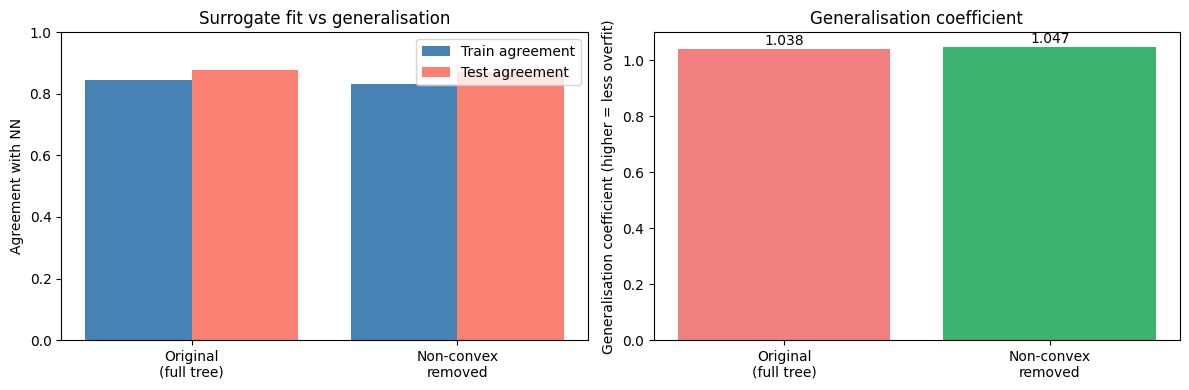

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Original\n(full tree)', 'Non-convex\nremoved']
x = np.arange(2)

axes[0].bar(x - 0.2, [b_tr, c_tr], 0.4, label='Train agreement', color='steelblue')
axes[0].bar(x + 0.2, [b_te, c_te], 0.4, label='Test agreement',  color='salmon')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Agreement with NN')
axes[0].set_title('Surrogate fit vs generalisation'); axes[0].legend()

axes[1].bar(x, [b_gc, c_gc], color=['lightcoral', 'mediumseagreen'])
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Generalisation coefficient (higher = less overfit)')
axes[1].set_title('Generalisation coefficient')
for i, v in enumerate([b_gc, c_gc]):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

### Headline: the pruned surrogate beats the GRU

Same metric (true-label test ÷ train) for both. If removal really cuts overfitting, the
pruned surrogate's gen-coef should pass the GRU's.

Model                                 Train     Test   Gen-coef
----------------------------------------------------------------
GRU (network being explained)        0.8583   0.7532     0.8776
Simplex-tree surrogate               0.7899   0.7143     0.9043
----------------------------------------------------------------
Surrogate gen-coef 0.9043  vs  GRU gen-coef 0.8776  -> HIGHER (the surrogate overfits less than the GRU)
Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy (surrogate test acc 0.7143 is still below the GRU 0.7532).


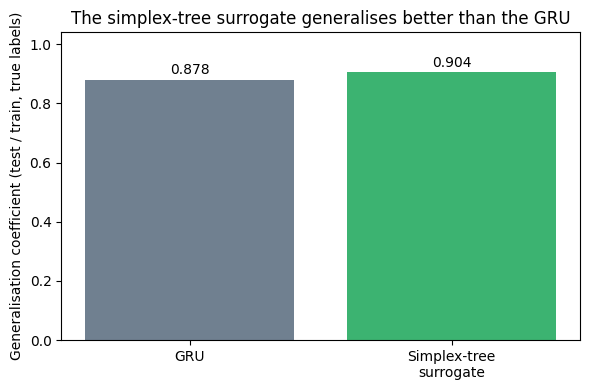

In [11]:
def gen_coef_true(predict_fn):
    """True-label generalisation coefficient = test_acc / train_acc."""
    tr = accuracy_score(y_train, predict_fn(X_train))
    te = accuracy_score(y_test,  predict_fn(X_test))
    return tr, te, te / tr

nn_tr, nn_te, nn_gc = gen_coef_true(lambda Z: nn_predict(nn_model, Z))
p_tr,  p_te,  p_gc  = gen_coef_true(stc_convex.predict)

print(f'{"Model":34s} {"Train":>8s} {"Test":>8s} {"Gen-coef":>10s}')
print('-' * 64)
print(f'{"GRU (network being explained)":34s} {nn_tr:>8.4f} {nn_te:>8.4f} {nn_gc:>10.4f}')
print(f'{"Simplex-tree surrogate":34s} {p_tr:>8.4f} {p_te:>8.4f} {p_gc:>10.4f}')
print('-' * 64)
print(f'Surrogate gen-coef {p_gc:.4f}  vs  GRU gen-coef {nn_gc:.4f}  '
      f'-> {"HIGHER (the surrogate overfits less than the GRU)" if p_gc > nn_gc else "not higher"}')
print('Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy '
      f'(surrogate test acc {p_te:.4f} is still below the GRU {nn_te:.4f}).')

fig, ax = plt.subplots(figsize=(6, 4))
names = ['GRU', 'Simplex-tree\nsurrogate']
vals  = [nn_gc, p_gc]
bars = ax.bar(names, vals, color=['slategray', 'mediumseagreen'])
ax.set_ylabel('Generalisation coefficient (test / train, true labels)')
ax.set_title('The simplex-tree surrogate generalises better than the GRU')
ax.set_ylim(0, max(vals) * 1.15)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## Experiment 2 — LIME's explanation vector points *out* of the target class in a non-convex region

The NN assigns $x_0$ a class — call it the **target** class (the class LIME is explaining). At
$x_0$ LIME fits a local linear model $g(x)=b+w^\top z(x)$, $z=(x-\mu)/\sigma$. Its weight vector
$w$ is meant to point in the direction of **increasing target membership**: along
$d=\mathrm{target}\cdot\widehat{w/\sigma}$, LIME believes you go *deeper into* the target class.

We do not move the NN or its boundary — we only **follow LIME's vector** from $x_0$:
$$x(\alpha)=\mathrm{clip}(x_0+\alpha\,d,\;0,1),\qquad \alpha\ge 0 .$$
Because $g$ is linear, $P_\text{LIME}(\text{target})$ only **increases** — LIME insists this whole
direction is target territory. The claim is that this is **false in a non-convex region**: the
vector points into an area LIME *labels* as target, but the **NN** is actually leaving the target
class there, because one straight direction cannot follow a non-convex region.

1. pick a point $x_0$ inside a non-convex region (found via the simplex tree);
2. extract LIME's vector $w$ at $x_0$;
3. read off the most influential features (largest $|w|$);
4. follow $d$ — the direction LIME claims is "deeper into the target class";
5. show that, because the region is **non-convex**, $P_\text{NN}(\text{target})$ drops below
   $0.5$: the point the vector pointed to is **not really target** — the NN has exited the target
   class. As a control, at a **convex** point the same vector does stay inside the target class,
   so the failure is caused by non-convexity, not by LIME or the step size.

In [12]:
try:
    import lime, lime.lime_tabular
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime'])
    import lime, lime.lime_tabular


def nn_predict_proba(X_):
    """Return [P(-1), P(+1)] for LIME / probing."""
    arr = np.atleast_2d(np.asarray(X_, dtype=np.float32))
    nn_model.eval()
    with torch.no_grad():
        p = nn_model(torch.tensor(arr).to(device)).cpu().numpy().flatten()
    return np.column_stack([1 - p, p])


def lime_explain(point, num_samples=3000, seed=0):
    """Fit LIME at `point` and expose its linear model in the ORIGINAL feature space.
    Returns (LIME weights toward +1, P(+1) prediction fn, feature-space gradient)."""
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train, mode='classification', feature_names=feature_names,
        class_names=['neg', 'pos'], discretize_continuous=False, random_state=seed)
    exp = explainer.explain_instance(point, nn_predict_proba, num_features=n_features,
                                     num_samples=num_samples, labels=(1,))
    coef = np.zeros(n_features)                      # LIME weights (standardised space), class +1
    for i, w in exp.local_exp[1]:
        coef[i] = w
    intercept = exp.intercept[1]
    mean_, scale_ = explainer.scaler.mean_, explainer.scaler.scale_
    def lime_p(x):                                   # LIME local-model P(+1) at feature-space x
        xs = (np.atleast_2d(x) - mean_) / scale_
        return intercept + xs.dot(coef)
    grad = coef / scale_                             # dP(+1)/dx in feature space
    return coef, intercept, lime_p, grad


ALPHA = np.linspace(0, 0.4, 81)              # step size along LIME's target-reinforcing direction

def push(point):
    """LIME explains the NN's decision at `point`; its `target` class is the NN's prediction there.
    Step along the direction LIME says reinforces that target class:
        d = target * (w/sigma),  normalised,   x(a) = clip(x0 + a*d, 0, 1),  a in ALPHA.
    Returns: ALPHA, f_t = NN P(target) along the step, g_t = LIME P(target) (clipped),
             target (+-1), the LIME weight vector w, and the unit direction d."""
    point = np.asarray(point, dtype=np.float32)
    coef, intercept, lime_p, grad = lime_explain(point)
    target = 1.0 if nn_predict_proba(point)[0, 1] >= 0.5 else -1.0
    d = target * grad
    nrm = np.linalg.norm(d)
    d = d / nrm if nrm > 0 else d
    xs = np.clip(point + np.outer(ALPHA, d), 0, 1)
    f = nn_predict_proba(xs)[:, 1]                   # NN P(+1)
    g = np.clip(lime_p(xs), 0, 1)                    # LIME P(+1)
    f_t = f if target > 0 else 1.0 - f               # NN P(target)
    g_t = g if target > 0 else 1.0 - g               # LIME P(target)
    return ALPHA, f_t, g_t, target, coef, d

In [13]:
nn_p_test = nn_predict_proba(X_test)[:, 1]
nc_pool   = np.where(test_in_nc)[0]            # test points inside non-convex simplices (step 1)
conv_pool = np.where(~test_in_nc)[0]

def target_class(i):
    return +1 if nn_p_test[i] >= 0.5 else -1

# Non-convex demo: LIME's target-reinforcing step makes the NN LEAVE the target class
# (P_NN(target) drops below 0.5). Pick the most dramatic departure.
nc_idx, nc_score = None, -np.inf
for i in nc_pool:
    _, f_t, g_t, _, _, _ = push(X_test[i])
    if g_t[-1] > g_t[0] and f_t.min() < 0.5:                 # LIME goes deeper in, NN leaves
        score = (f_t[0] - 0.5) + (0.5 - f_t.min())
        if score > nc_score:
            nc_idx, nc_score = int(i), score

# Convex contrast: the same step keeps the NN INSIDE the target class (LIME's advice is right).
conv_idx, conv_score = None, -np.inf
for i in conv_pool:
    _, f_t, g_t, _, _, _ = push(X_test[i])
    if g_t[-1] > g_t[0] and f_t.min() >= 0.5 and (f_t[-1] - f_t[0]) > conv_score:
        conv_idx, conv_score = int(i), float(f_t[-1] - f_t[0])

print(f'Non-convex demo point : idx {nc_idx}  target class={target_class(nc_idx):+d}  '
      f'P(target)={max(nn_p_test[nc_idx], 1 - nn_p_test[nc_idx]):.3f}')
print(f'Convex contrast point : idx {conv_idx}  target class={target_class(conv_idx):+d}  '
      f'P(target)={max(nn_p_test[conv_idx], 1 - nn_p_test[conv_idx]):.3f}')


Non-convex demo point : idx 52  target class=+1  P(target)=0.937
Convex contrast point : idx 112  target class=+1  P(target)=0.889


In [14]:
# Steps 2-5 at the non-convex point: read LIME's vector, step to reinforce the target class,
# and watch the NN leave it.
x0 = X_test[nc_idx].astype(np.float32)
alphas, f_t, g_t, target, w_nc, d_nc = push(x0)

a_star = int(np.argmin(f_t))                         # step where the NN is furthest from target
x_new  = np.clip(x0 + alphas[a_star] * d_nc, 0, 1)
order  = np.argsort(-np.abs(w_nc))                   # most influential features first

np.set_printoptions(precision=4, suppress=True, sign='+')
print(f'target class (the NN decision at x0) = {int(target):+d}')
print('LIME weight vector  w =', w_nc, '  (toward class +1)')
print('most influential features:', [feature_names[k] for k in order[:2]], '\n')

print(f'{"feature":8s} {"x0":>9s} {"x_new":>9s} {"delta":>9s}   (w)')
for k in order:
    print(f'{feature_names[k]:8s} {x0[k]:>9.4f} {x_new[k]:>9.4f} {x_new[k]-x0[k]:>+9.4f}   {w_nc[k]:+.3f}')

print(f'\nstep size alpha* = {alphas[a_star]:.3f}   (along LIME\'s target-reinforcing direction)')
print(f'LIME P(target) : {g_t[0]:.3f} -> {g_t[a_star]:.3f}   (LIME: deeper INTO the target class)')
print(f'NN   P(target) : {f_t[0]:.3f} -> {f_t[a_star]:.3f}   '
      f'(NN: {"stays in" if f_t[a_star] >= 0.5 else "LEAVES"} the target class)')
print(f'\n=> LIME\'s vector says this step drives x0 deeper into its target class, but the NN '
      f'actually {"stays inside" if f_t[a_star] >= 0.5 else "leaves"} the target class: '
      f'LIME is wrong in this non-convex region.')

target class (the NN decision at x0) = +1
LIME weight vector  w = [+0.0506 +0.1875 +0.0823 +0.1088]   (toward class +1)
most influential features: ['plas', 'pedi'] 

feature         x0     x_new     delta   (w)
plas        0.5871    0.6877   +0.1006   +0.187
pedi        0.0880    0.1681   +0.0801   +0.109
mass        0.4581    0.5194   +0.0613   +0.082
preg        0.0000    0.0270   +0.0270   +0.051

step size alpha* = 0.145   (along LIME's target-reinforcing direction)
LIME P(target) : 0.384 -> 0.586   (LIME: deeper INTO the target class)
NN   P(target) : 0.937 -> 0.182   (NN: LEAVES the target class)

=> LIME's vector says this step drives x0 deeper into its target class, but the NN actually leaves the target class: LIME is wrong in this non-convex region.


### LIME's target-reinforcing step: non-convex (leaves target) vs convex (stays in)

Both panels push along the direction LIME says reinforces the NN's **target** class,
$x(\alpha)=\mathrm{clip}(x_0+\alpha d,0,1)$, and plot $P(\text{target})$. LIME (dashed) is linear,
so its $P(\text{target})$ only rises — it is sure we go deeper into the target. At the
**non-convex** point the NN's $P(\text{target})$ **drops below $0.5$**: the point leaves the
target class, so LIME's advice backfires. At the **convex** point the NN stays above $0.5$ —
LIME's advice is correct.

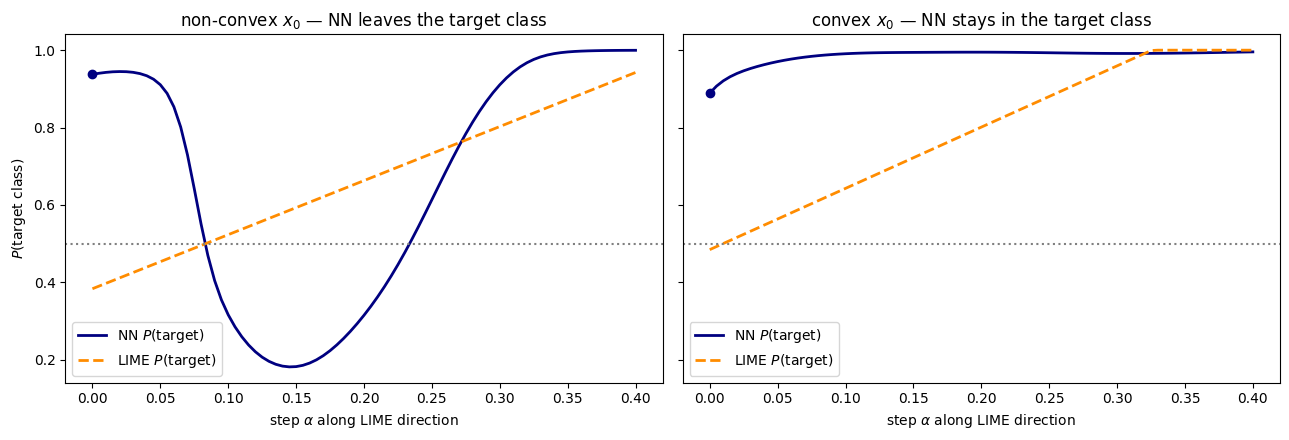

point         P(target) start  P(target) min   verdict
--------------------------------------------------------------
non-convex              0.937          0.182   LEAVES target (LIME wrong)
convex                  0.889          0.889   stays in target (LIME ok)

LIME says "deeper into the target class" in both cases. The NN obeys only at the convex
point; at the non-convex point the same step makes the NN leave the target class.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, idx, title in [(axes[0], nc_idx,   'non-convex $x_0$ — NN leaves the target class'),
                       (axes[1], conv_idx, 'convex $x_0$ — NN stays in the target class')]:
    a, f_t, g_t, _, _, _ = push(X_test[idx])
    ax.plot(a, f_t, color='navy',       lw=2,          label='NN $P(\\mathrm{target})$')
    ax.plot(a, g_t, color='darkorange', lw=2, ls='--', label='LIME $P(\\mathrm{target})$')
    ax.axhline(0.5, color='gray', ls=':')
    ax.scatter([0], [f_t[0]], color='navy', zorder=5)
    ax.set_xlabel(r'step $\alpha$ along LIME direction'); ax.set_title(title); ax.legend(loc='best')
axes[0].set_ylabel('$P(\\mathrm{target\\ class})$')
plt.tight_layout(); plt.show()

_, f_n, g_n, _, _, _ = push(X_test[nc_idx])
_, f_c, g_c, _, _, _ = push(X_test[conv_idx])
print(f'{"point":12s} {"P(target) start":>16s} {"P(target) min":>14s}   verdict')
print('-' * 62)
print(f'{"non-convex":12s} {f_n[0]:>16.3f} {f_n.min():>14.3f}   LEAVES target (LIME wrong)')
print(f'{"convex":12s} {f_c[0]:>16.3f} {f_c.min():>14.3f}   stays in target (LIME ok)')
print('\nLIME says "deeper into the target class" in both cases. The NN obeys only at the convex')
print('point; at the non-convex point the same step makes the NN leave the target class.')